In [2]:
suppressPackageStartupMessages(library(tidyverse))
#library(ggnewscale)
library(ggideogram)
#library(ggpubr)
#library(patchwork)
source("../scripts/00_R_presets.R")

Warning message:
“package ‘ggplot2’ was built under R version 4.5.3”
Warning message:
“package ‘purrr’ was built under R version 4.5.3”
Warning message:
“package ‘dplyr’ was built under R version 4.5.3”
Scanning ttf files in ../../doc/figures/helvetica ...

Extracting .afm files from .ttf files...

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/Helvetica Condensed Regular.ttf
 : Helvetica-Condensed already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/Helvetica Roman.ttf
 : Helvetica already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/helvetica_condensed.ttf
 : Helvetica-Condensed already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/Helvetica-Bold Oblique.ttf
 : Helvetica-BoldOblique already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/a

# Figure 1: Assembly QC

Subplots:
- A) QC Beesplot
- B) T2T overview
- C) Errors Plot
- S1) ReadQC
- S2) Chromosome Plot
- S3) NGX Plot

In [32]:
# Subfigure sizes 182mm = 7,16 inches
sizes <- list(
    "B" = c(7,1.35),       # QC Beesplot
    "A" = c(5,4),         # T2T Grid
    "C" = c(3,2),         # Errors Plot
    "D" = c(7,7),       # Ideogram
    "E" = c(5,4),         # T2T Grid with right legend
    "F" = c(4,3)          # NGX Plot
)

# Helper to access sizes
sizes <- lapply(sizes, function(x) setNames(x, c("1", "2")))

## A: T2T overview


In [5]:
# read data
dt_t2t <- read.table("../../doc/tables/for_plots/T2T_scaffolds.both.all.txt", header = TRUE, sep = "\t", stringsAsFactors = FALSE) %>%
    mutate(
        haplotype = case_when(
        grepl("haplotype1", contig) ~ "Hap 1",
        grepl("haplotype2", contig) ~ "Hap 2",
        TRUE ~ "Unknown"
        ),
        # Create sample_haplotype combination for x-axis
        sample_hap = paste(sample, haplotype, sep = "_"),
        # Clean up chromosome names (remove 'chr' prefix for sorting)
        chr_num = gsub("chr", "", chromosome),
        # Convert chromosome to factor with proper ordering
        chr_factor = factor(chromosome, levels = c(
        paste0("chr", 1:22), "chrX", "chrY"
        ))
)

head(dt_t2t)
print(unique(dt_t2t$sample))

,sample,contig,chromosome,contig_length,gap_length,ref_length,motif_length,n_gaps,total_gap_length_bed,mean_gap_size,max_gap_size,min_gap_size,gap_density,classification,haplotype,sample_hap,chr_num,chr_factor
,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<fct>
1,T2T00,haplotype1-0000001,chr1,245398328,115000,248387328,245398328,3,115000,38333.3,100000,7500,0.01,scaffold,Hap 1,T2T00_Hap 1,1,chr1
2,T2T00,haplotype2-0000045,chr1,245133717,22500,248387328,245133717,3,22500,7500.0,7500,7500,0.01,scaffold,Hap 2,T2T00_Hap 2,1,chr1
3,T2T00,haplotype1-0000004,chr10,136566791,35859,134758134,136566791,1,35859,35859.0,35859,35859,0.01,scaffold,Hap 1,T2T00_Hap 1,10,chr10
4,T2T00,haplotype2-0000048,chr10,136628182,15000,134758134,136628182,2,15000,7500.0,7500,7500,0.01,scaffold,Hap 2,T2T00_Hap 2,10,chr10
5,T2T00,haplotype1-0000019,chr11,137904311,0,135127769,137904311,0,0,0.0,0,0,0.00,contig,Hap 1,T2T00_Hap 1,11,chr11
6,T2T00,haplotype2-0000066,chr11,136649847,15000,135127769,136649847,2,15000,7500.0,7500,7500,0.01,scaffold,Hap 2,T2T00_Hap 2,11,chr11


 [1] "T2T00"     "T2T00_1"   "T2T00_2"   "T2T04"     "T2T04_1"   "T2T04_2"  
 [7] "T2T01"     "T2T02"     "T2T03"     "T2T05"     "T2T06"     "T2T07"    
[13] "T2T08"     "T2T09"     "T2T10"     "T2T11"     "T2T12"     "T2T13"    
[19] "T2T15"     "T2T16"     "T2T17"     "T2T18"     "T2T19"     "T2T_HG002"


In [6]:
# Create a complete grid of all sample-haplotype combinations and chromosomes
all_samples <- unique(dt_t2t$sample)  # Changed from df to dt_t2t
all_haplotypes <- c("Hap 1", "Hap 2")  # Match the haplotype labels from dt_t2t
all_chromosomes <- levels(dt_t2t$chr_factor)  # Changed from df to dt_t2t

# Create complete grid
complete_grid <- expand.grid(
    sample     = all_samples,
    haplotype  = all_haplotypes,
    chromosome = all_chromosomes,
    stringsAsFactors = FALSE
) %>%
    mutate(
        sample_hap = paste(sample, haplotype, sep = "_"),
        chr_factor = factor(chromosome, levels = all_chromosomes)
    )

# Load sex information
sample_sex <- read_tsv("../../data/sample_sex.tsv", show_col_types = FALSE) %>%
    select(sample = IID, SEX) %>%
    mutate(
        missing_2nd_X = SEX == 1,  # males have no 2nd X
        missing_Y     = SEX == 2   # females have no Y
    )

# Merge and assign coverage status
plot_data <- complete_grid %>%
    left_join(dt_t2t, by = c("sample", "haplotype", "sample_hap", "chr_factor")) %>%
    left_join(sample_sex, by = "sample") %>%
    mutate(
        coverage_status = case_when(
            # chrY: Hap 2 always missing (Y only ever on Hap 1)
            as.character(chr_factor) == "chrY" & haplotype == "Hap 2"                        ~ "Missing",
            # chrY: Hap 1 missing for females (no Y at all)
            missing_Y     & as.character(chr_factor) == "chrY" & haplotype == "Hap 1"        ~ "Missing",
            # chrX: Hap 1 missing for males (single X always on Hap 2)
            missing_2nd_X & as.character(chr_factor) == "chrX" & haplotype == "Hap 1"        ~ "Missing",
            is.na(contig)                                                 ~ "Multiple contigs",
            n_gaps == 0                                                   ~ "Complete",
            n_gaps == 1 & gap_length <= 50000                            ~ "Single Small Gap",
            n_gaps == 1 & gap_length >  50000                            ~ "Single Large Gap",
            n_gaps > 1  & gap_length <= 100000                           ~ "Multiple Small Gaps",
            n_gaps > 1  & gap_length >  100000                           ~ "Multiple Large Gaps",
            TRUE                                                          ~ "Other"
        ),
        coverage_status_simple = case_when(
            coverage_status == "Complete"   ~ "Complete T2T",
            coverage_status == "Missing"    ~ "Missing",
            coverage_status %in% c("Single Small Gap", "Single Large Gap",
                                   "Multiple Small Gaps", "Multiple Large Gaps") ~ "Near T2T",
            TRUE ~ "Multiple contigs"
        )
    )

head(plot_data)

,sample,haplotype,chromosome.x,sample_hap,chr_factor,contig,chromosome.y,contig_length,gap_length,ref_length,⋯,max_gap_size,min_gap_size,gap_density,classification,chr_num,SEX,missing_2nd_X,missing_Y,coverage_status,coverage_status_simple
,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<chr>,<int>,<int>,<int>,⋯,<int>,<int>,<dbl>,<chr>,<chr>,<dbl>,<lgl>,<lgl>,<chr>,<chr>
1,T2T00,Hap 1,chr1,T2T00_Hap 1,chr1,haplotype1-0000001,chr1,245398328,115000,248387328,⋯,100000,7500,0.01,scaffold,1,1,TRUE,FALSE,Multiple Large Gaps,Near T2T
2,T2T00_1,Hap 1,chr1,T2T00_1_Hap 1,chr1,haplotype1-0000004,chr1,247165570,15000,248387328,⋯,7500,7500,0.01,scaffold,1,1,TRUE,FALSE,Multiple Small Gaps,Near T2T
3,T2T00_2,Hap 1,chr1,T2T00_2_Hap 1,chr1,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,2,FALSE,TRUE,Multiple contigs,Multiple contigs
4,T2T04,Hap 1,chr1,T2T04_Hap 1,chr1,haplotype1-0000011,chr1,251430232,24684,248387328,⋯,17184,7500,0.01,scaffold,1,1,TRUE,FALSE,Multiple Small Gaps,Near T2T
5,T2T04_1,Hap 1,chr1,T2T04_1_Hap 1,chr1,haplotype1-0000008,chr1,251601345,15000,248387328,⋯,7500,7500,0.01,scaffold,1,1,TRUE,FALSE,Multiple Small Gaps,Near T2T
6,T2T04_2,Hap 1,chr1,T2T04_2_Hap 1,chr1,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,2,FALSE,TRUE,Multiple contigs,Multiple contigs


In [ ]:
# Number of T2T contigs and T2T scaffolds per sample
# (denominator = evaluable slots, i.e. excluding chromosomes marked as "Missing" due to sex)

n_eval_per_sample <- plot_data %>%
    filter(coverage_status != "Missing") %>%
    group_by(sample) %>%
    summarise(n_eval = n(), .groups = "drop")

n_samples_t2t <- n_distinct(plot_data$sample)
n_total_eval  <- sum(n_eval_per_sample$n_eval)

# ── Overall summary ───────────────────────────────────────────────────────────
overall_summary <- plot_data %>%
    filter(classification %in% c("contig", "scaffold")) %>%
    group_by(classification) %>%
    summarise(count = n(), .groups = "drop") %>%
    mutate(
        percentage = round(count / n_total_eval * 100, 2)
    ) %>%
    arrange(desc(count))

cat(sprintf("Samples in plot_data: %d\n", n_samples_t2t))
cat(sprintf("Total evaluable slots: %d\n", n_total_eval))
cat(sprintf("Evaluable slots per sample (expected ~46): %.1f\n", n_total_eval / n_samples_t2t))
overall_summary



In [ ]:
# Per-sample summary: T2T contigs and scaffolds
per_sample_t2t <- plot_data %>%
    filter(classification %in% c("contig", "scaffold")) %>%
    group_by(sample, classification) %>%
    summarise(count = n(), .groups = "drop") %>%
    pivot_wider(names_from = classification, values_from = count, values_fill = 0L) %>%
    left_join(n_eval_per_sample, by = "sample") %>%
    mutate(
        total_t2t    = contig + scaffold,
        pct_contig   = round(contig   / n_eval * 100, 1),
        pct_scaffold = round(scaffold / n_eval * 100, 1),
        pct_t2t      = round(total_t2t / n_eval * 100, 1)
    ) %>%
    rename(n_t2t_contig = contig, n_t2t_scaffold = scaffold) %>%
    arrange(desc(total_t2t))

cat(sprintf("Median T2T contigs  per sample : %g\n", median(per_sample_t2t$n_t2t_contig)))
cat(sprintf("Median T2T scaffolds per sample: %g\n", median(per_sample_t2t$n_t2t_scaffold)))
cat(sprintf("Median total T2T    per sample : %g\n", median(per_sample_t2t$total_t2t)))
cat(sprintf("Range total T2T                : %g – %g\n",
    min(per_sample_t2t$total_t2t), max(per_sample_t2t$total_t2t)))

per_sample_t2t



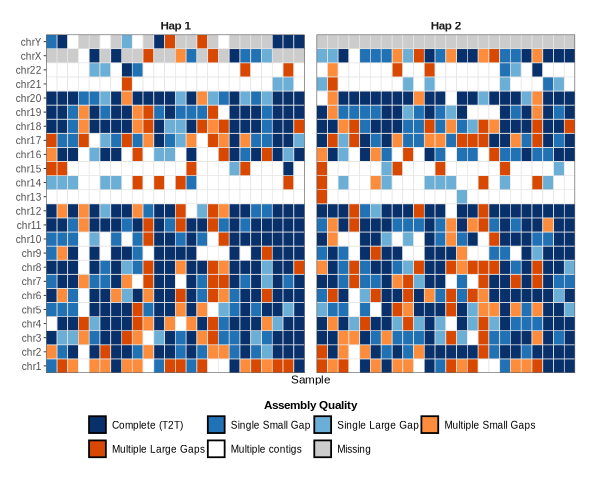

In [114]:
# Define colors for coverage status with clear quality progression
status_colors <- c(
    "Multiple contigs" = "#ffffff",           # White
    "Missing" = "#cccccc",             # Light grey
    "Complete" = "#08306b",            # Dark navy blue (excellent)
    "Single Small Gap" = "#2171b5",    # Medium blue (very good)
    "Single Large Gap" = "#6baed6",    # Light blue (good)
    "Multiple Small Gaps" = "#fd8d3c", # Orange (concerning)
    "Multiple Large Gaps" = "#d94801", # Dark orange/red (problematic)
    "Other" = "#e48bd8"                # Pink (should not appear)
)

# Create the main plot
fig1_A_t2t_grid <- ggplot(plot_data, aes(x = sample, y = chr_factor)) +
    geom_tile(aes(fill = coverage_status), color = "grey90", linewidth = 0.2) +
    scale_fill_manual(
        values = status_colors, 
        name = "Assembly Quality",
        # Order legend by quality (best to worst)
        breaks = c("Complete", "Single Small Gap", "Single Large Gap", 
                  "Multiple Small Gaps", "Multiple Large Gaps", "Multiple contigs", "Missing", "Other"),
        # Optional: Add more descriptive labels
        labels = c("Complete (T2T)", "Single Small Gap", "Single Large Gap", 
                  "Multiple Small Gaps", "Multiple Large Gaps", "Multiple contigs", "Missing", "Other")
    ) +
    facet_wrap(~ haplotype, nrow = 1) +
    scale_x_discrete(expand = c(0, 0)) +
    scale_y_discrete(expand = c(0, 0)) +
    labs(
        x = "Sample",
        y = NULL
    ) +
    theme(
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        legend.position = "bottom",
    ) +
    guides(fill = guide_legend(
        title.position = "top",
        title.hjust = 0.5,
        nrow = 2,  # Arrange legend in 2 rows for better space usage
        byrow = TRUE,
        override.aes = list(color = "black", linewidth = 0.5)  # Add borders to legend squares
    ))

ggsave("../../doc/figures/fig1_A_t2t_grid.png", fig1_A_t2t_grid, width = sizes[["A"]]["1"], height = sizes[["A"]]["2"])
ggsave("../../doc/figures/fig1_A_t2t_grid.pdf", fig1_A_t2t_grid, width = sizes[["A"]]["1"], height = sizes[["A"]]["2"])

options(repr.plot.width = sizes[["A"]]["1"], repr.plot.height = sizes[["A"]]["2"])
fig1_A_t2t_grid

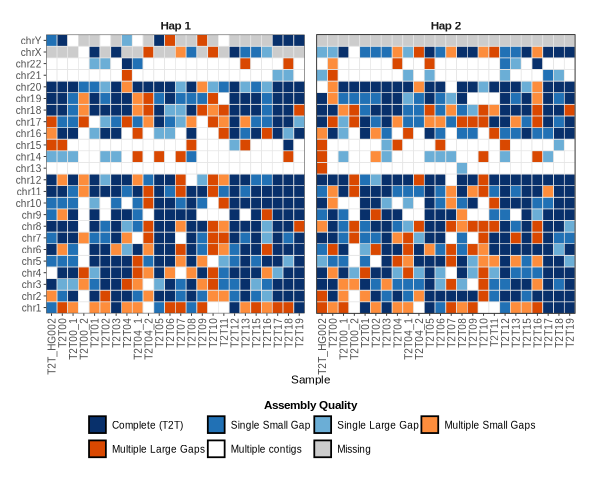

In [115]:
fig1_A_t2t_grid_samplenames <- fig1_A_t2t_grid +
    theme(
        axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1, size = 6),
        axis.ticks.x = element_line()
    )

ggsave("../../doc/figures/fig1_A_t2t_grid_samplenames.png", fig1_A_t2t_grid_samplenames, width = sizes[["A"]]["1"], height = sizes[["A"]]["2"])
ggsave("../../doc/figures/fig1_A_t2t_grid_samplenames.pdf", fig1_A_t2t_grid_samplenames, width = sizes[["A"]]["1"], height = sizes[["A"]]["2"])

options(repr.plot.width = sizes[["A"]]["1"], repr.plot.height = sizes[["A"]]["2"])
fig1_A_t2t_grid_samplenames

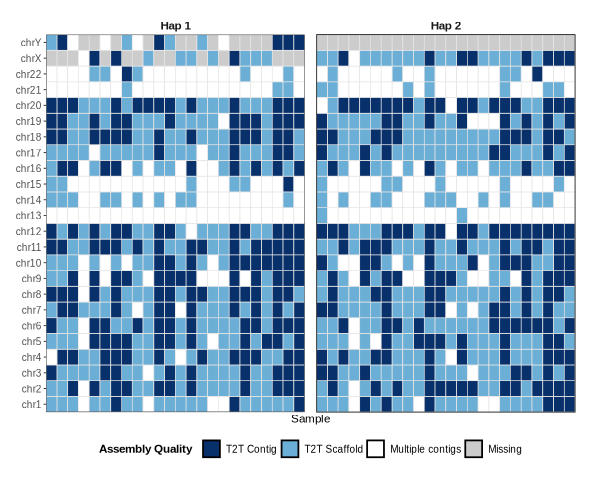

In [116]:
# Define colors for coverage status with clear quality progression
status_colors_simple <- c(
    "Complete T2T" = "#08306b",            # Dark navy blue (excellent)
    "Near T2T" = "#6baed6",    # Light blue (good)
    "Multiple contigs" = "#ffffff",               # White
    "Missing" = "#cccccc"             # Light grey
)

# Create the main plot
fig1_A_t2t_grid_simple <- ggplot(plot_data, aes(x = sample, y = chr_factor)) +
    geom_tile(aes(fill = coverage_status_simple), color = "grey90", linewidth = 0.2) +
    scale_fill_manual(
        values = status_colors_simple, 
        name = "Assembly Quality",
        # Order legend by quality (best to worst)
        breaks = c("Complete T2T", "Near T2T", "Multiple contigs", "Missing"),
        # Optional: Add more descriptive labels
        labels = c("T2T Contig", "T2T Scaffold", "Multiple contigs", "Missing")
    ) +
    facet_wrap(~ haplotype, nrow = 1) +
    scale_x_discrete(expand = c(0, 0)) +
    scale_y_discrete(expand = c(0, 0)) +
    labs(
        x = "Sample",
        y = NULL
    ) +
    theme(
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        legend.position = "bottom",
    ) +
    guides(fill = guide_legend(
        title.position = "left",
        #ncol = 1,  # Arrange legend in 2 rows for better space usage
        #byrow = TRUE,
        override.aes = list(color = "black", linewidth = 0.5)  # Add borders to legend squares
    ))

ggsave("../../doc/figures/fig1_A_t2t_grid_simple.png", fig1_A_t2t_grid_simple, width = sizes[["E"]]["1"], height = sizes[["E"]]["2"])
ggsave("../../doc/figures/fig1_A_t2t_grid_simple.pdf", fig1_A_t2t_grid_simple, width = sizes[["E"]]["1"], height = sizes[["E"]]["2"])

options(repr.plot.width = sizes[["E"]]["1"], repr.plot.height = sizes[["E"]]["2"])
fig1_A_t2t_grid_simple

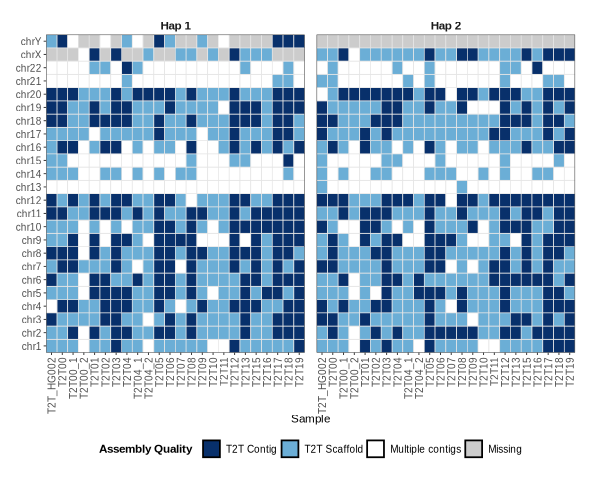

In [117]:
fig1_A_t2t_grid_simple_samplenames <- fig1_A_t2t_grid_simple +
    theme(
        axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1, size = 6),
        axis.ticks.x = element_line()
    )

ggsave("../../doc/figures/fig1_A_t2t_grid_simple_samplenames.png", fig1_A_t2t_grid_simple_samplenames, width = sizes[["A"]]["1"], height = sizes[["A"]]["2"])
ggsave("../../doc/figures/fig1_A_t2t_grid_simple_samplenames.pdf", fig1_A_t2t_grid_simple_samplenames, width = sizes[["A"]]["1"], height = sizes[["A"]]["2"])

options(repr.plot.width = sizes[["A"]]["1"], repr.plot.height = sizes[["A"]]["2"])
fig1_A_t2t_grid_simple_samplenames

## B: QC Beesplot

Plot some of the most important Assembly QC values along with comparison to HPRC samples

In [11]:
hprc <- read_tsv("../../doc/tables/qc_hprc_full.tsv", show_col_types = FALSE) %>%
    mutate(source = "hprc")

samples <- read_tsv("../../doc/tables/qc_samples_table_full.tsv", show_col_types = FALSE) %>%
    mutate(source = "samples")

sample_metadata <- read_tsv("../../doc/tables/participant_metadata_clean.tsv", show_col_types = FALSE) %>%
    select(asm_name = t2t_identifier, sex)

hprc_metadata <- read_csv(
    "../../data/ref/hprc/pre_release2_v0.6.1/hprc_release2_sample_metadata.csv",
    show_col_types = FALSE
) %>%
    select(asm_name = sample_id, sex) %>%
    mutate(sex = str_to_title(sex))    # "male"/"female" → "Male"/"Female"

sex_lookup <- bind_rows(sample_metadata, hprc_metadata)

dt_qc <- bind_rows(hprc, samples) %>%
    filter(haplotype != "both") %>%
    left_join(sex_lookup, by = "asm_name") %>%
    mutate(sex = ifelse(is.na(sex) & asm_name == "T2T_HG002", "Male", sex))


head(dt_qc)
tail(dt_qc)

metric,value,haplotype,asm_method,asm_name,source,chromosome,sex
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
length,2.947895e+09,haplotype1,phased_hprc,HG002,hprc,NA,Male
ref_covered,9.075000e-01,haplotype1,phased_hprc,HG002,hprc,NA,Male
asm_covered,9.653000e-01,haplotype1,phased_hprc,HG002,hprc,NA,Male
length,3.051530e+09,haplotype2,phased_hprc,HG002,hprc,NA,Male
ref_covered,9.415000e-01,haplotype2,phased_hprc,HG002,hprc,NA,Male
asm_covered,9.686000e-01,haplotype2,phased_hprc,HG002,hprc,NA,Male


metric,value,haplotype,asm_method,asm_name,source,chromosome,sex
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
MSC,0.05290991,haplotype1,phased_verkko,T2T18,samples,NA,Male
MSC,0.01533861,haplotype2,phased_verkko,T2T18,samples,NA,Male
MSC,0.05321446,haplotype1,phased_verkko,T2T19,samples,NA,Male
MSC,0.01619691,haplotype2,phased_verkko,T2T19,samples,NA,Male
MSC,0.05440501,haplotype1,phased_verkko,T2T_HG002,samples,NA,Male
MSC,0.01896561,haplotype2,phased_verkko,T2T_HG002,samples,NA,Male


In [13]:
metric_labels <- c(
    "length" = "Length (Mb)",
    "ref_covered" = "Ref covered (%)",
    "asm_covered" = "Asm. covered (%)",
    "inter-chromosomal_misjoins" = "Misjoins trans",
    "intra-chromosomal_gaps" = "Gaps cis",
    "candidate_inversions_in_the_middle" = "Inv. Mid",
    "candidate_inversions_at_contig_ends" = "Inv. Ends",
    "n_t2t_scaffold" = "n T2T Scaffolds",
    "n_t2t_contig" = "n T2T Contigs",
    "total_n_count" = "Total N Count",
    "total_gaps" = "Total Gaps",
    "n_contigs" = "n Contigs",
    "n_contigs_over_10mb" = "n Contigs >10 Mb",
    "genome_completeness" = "Completeness",
    "MMC" = "MMC",
    "MSC" = "MSC"
)

source_labels <- c(
    "hprc" = "HPRC",
    "samples" = "Samples"
)

sample_labels <- c(
    "TRUE" = "HG002",
    "FALSE" = "Other"
)

haplotype_labels <- c(
    "haplotype1" = "Hap 1",
    "haplotype2" = "Hap 2"
)

# Update dt_qc with renamed fields
dt_qc_u <- dt_qc %>%
    mutate(
        metric = recode(metric, !!!metric_labels),
        source = recode(source, !!!source_labels),
        hg002_sample = ifelse(str_detect(string = asm_name, pattern = "HG002$"), "HG002", "Other"),
        haplotype = recode(haplotype, !!!haplotype_labels),
        sex = factor(sex, levels = c("Male", "Female"))
    )

head(dt_qc_u)

metric,value,haplotype,asm_method,asm_name,source,chromosome,sex,hg002_sample
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>
Length (Mb),2.947895e+09,Hap 1,phased_hprc,HG002,HPRC,NA,Male,HG002
Ref covered (%),9.075000e-01,Hap 1,phased_hprc,HG002,HPRC,NA,Male,HG002
Asm. covered (%),9.653000e-01,Hap 1,phased_hprc,HG002,HPRC,NA,Male,HG002
Length (Mb),3.051530e+09,Hap 2,phased_hprc,HG002,HPRC,NA,Male,HG002
Ref covered (%),9.415000e-01,Hap 2,phased_hprc,HG002,HPRC,NA,Male,HG002
Asm. covered (%),9.686000e-01,Hap 2,phased_hprc,HG002,HPRC,NA,Male,HG002


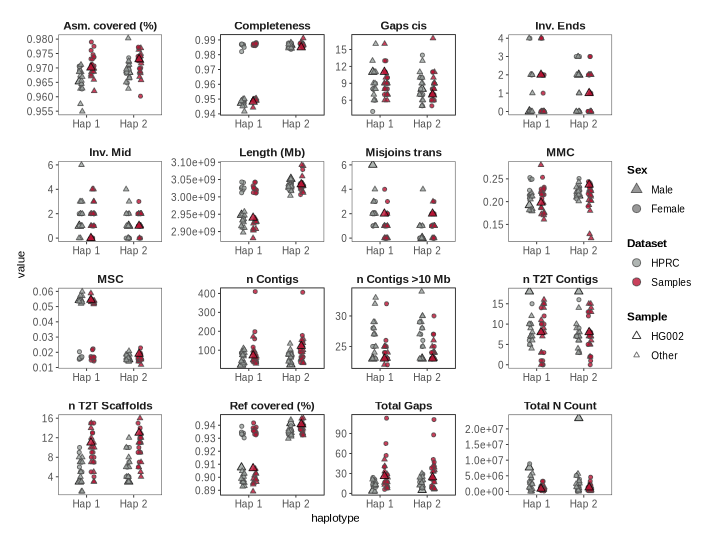

In [30]:
p_qc_beesplot_full <- ggplot(dt_qc_u, aes(
    x = haplotype, y = value,
    fill = source, 
    shape = sex, colour = hg002_sample, size = hg002_sample,
    group = source
)) +
    geom_point(
        position = position_jitterdodge(jitter.width = 0.15, dodge.width = 0.5),
        stroke = 0.4,
        alpha = 0.8
    ) +
    scale_fill_manual(values = col_source, name = "Dataset") +
    scale_shape_manual(values = c("Female" = 21, "Male" = 24), name = "Sex", na.value = 21) +
    scale_colour_manual(values = c("HG002" = "black", "Other" = "grey30"), name = "Sample") +
    scale_size_manual(values = c("HG002" = 1.5, "Other" = 0.9), name = "Sample") +
    guides(
        fill   = guide_legend(override.aes = list(shape = 21, size = 2, colour = "grey30", stroke = 0.4)),
        shape  = guide_legend(override.aes = list(fill = "grey50", size = 2, colour = "grey30", stroke = 0.4)),
        colour = guide_legend(override.aes = list(shape = 24, fill = "white", size = c(1.5, 0.9), stroke = 0.4))
    ) +
    facet_wrap(~metric, scales = "free")

ggsave("../../doc/figures/qc_beesplot_full.png", p_qc_beesplot_full, width = 16 * 0.5, height = 9 * 0.5)
ggsave("../../doc/figures/qc_beesplot_full.pdf", p_qc_beesplot_full, width = 16 * 0.5, height = 9 * 0.5)
options(repr.plot.width = 12 * 0.5, repr.plot.height = 9 * 0.5)
p_qc_beesplot_full

Ignoring unknown labels:
• alpha : "Dataset"
Ignoring unknown labels:
• alpha : "Dataset"
Ignoring unknown labels:
• alpha : "Dataset"


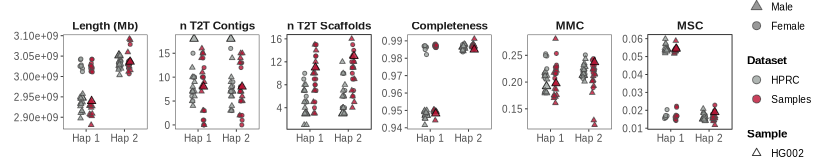

In [33]:
selection <- c(
    "Length (Mb)",
    "n T2T Contigs",
    "n T2T Scaffolds",
    "Completeness",
    "MMC",
    "MSC"
    )

p_qc_beesplot <- ggplot(dt_qc_u %>% filter(metric %in% selection) %>% mutate(metric = factor(metric, levels = selection)), aes(
    x = haplotype, y = value,
    fill = source, 
    shape = sex, colour = hg002_sample, size = hg002_sample,
    group = source
    )) +
    geom_point(
        position = position_jitterdodge(jitter.width = 0.15, dodge.width = 0.5),
        stroke = 0.4,
        alpha = 0.8
    ) +
    scale_fill_manual(values = col_source, name = "Dataset") +
    scale_shape_manual(values = c("Female" = 21, "Male" = 24), name = "Sex", na.value = 21) +
    scale_colour_manual(values = c("HG002" = "black", "Other" = "grey30"), name = "Sample") +
    scale_size_manual(values = c("HG002" = 1.5, "Other" = 0.9), name = "Sample") +
    guides(
        fill   = guide_legend(override.aes = list(shape = 21, size = 2, colour = "grey30", stroke = 0.4)),
        shape  = guide_legend(override.aes = list(fill = "grey50", size = 2, colour = "grey30", stroke = 0.4)),
        colour = guide_legend(override.aes = list(shape = 24, fill = "white", size = c(1.5, 0.9), stroke = 0.4))
    ) +
    facet_wrap(~metric, scales = "free", nrow = 1) +
    labs(x = NULL, y = NULL, fill = "Dataset", alpha = "Dataset")


ggsave("../../doc/figures/fig1_B_qc_beesplot.png", p_qc_beesplot, width = sizes[["B"]]["1"] , height = sizes[["B"]]["2"])
ggsave("../../doc/figures/fig1_B_qc_beesplot.pdf", p_qc_beesplot, width = sizes[["B"]]["1"] , height = sizes[["B"]]["2"])

options(repr.plot.width = sizes[["B"]]["1"], repr.plot.height = sizes[["B"]]["2"])
p_qc_beesplot

## S1: ReadQC 

In [122]:
dt_readqc <- read_tsv("../../doc/tables/publication/minknow_metrics_processed_UL.tsv", show_col_types = F)
head(dt_readqc)

flow_cell_id,kit_type,run_start_time,run_end_time,estimated_n50,bases_called_pass,reads_called_pass,elapsed_time_seconds,name_external,run_time_hours
<chr>,<chr>,<dttm>,<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
PAY80694,SQK-ULK114,2024-12-04 15:15:21,2024-12-11 08:27:32,53714.63,112470746486,4356332,571645,Unknown,158.7903
PBA32113,SQK-ULK114,2024-11-11 13:25:36,2024-11-16 13:31:47,67073.00,106573295444,3832146,432002,Unknown,120.0006
PBA36199,SQK-ULK114,2024-11-11 13:33:02,2024-11-16 13:39:14,77586.00,101170475091,2731211,432002,Unknown,120.0006
PBA75463,SQK-ULK114,2024-12-04 15:15:21,2024-12-11 08:27:32,52435.77,124700727272,4941389,571645,Unknown,158.7903
PBA75681,SQK-ULK114,2024-12-04 15:15:21,2024-12-11 08:27:32,46742.59,92561805832,4558778,571643,Unknown,158.7897
PBA75688,SQK-ULK114,2024-12-04 15:15:21,2024-12-11 08:27:32,28340.84,105671646178,7773711,571645,Unknown,158.7903


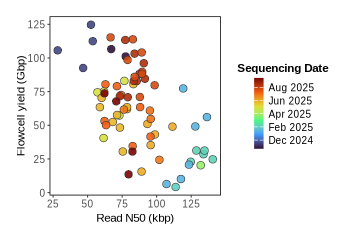

In [123]:
fig1_C_readqc <- ggplot(dt_readqc, aes(x = estimated_n50, y = bases_called_pass, fill = run_end_time)) +
    geom_point(shape = 21, colour = "grey20", alpha = 0.9, size = 2) +
    scale_x_continuous(labels = function(x) x / 1000, name = "Read N50 (kbp)") +
    scale_y_continuous(labels = function(y) y / 1e9, name = "Flowcell yield (Gbp)") +
    scale_fill_viridis_c(
        option = "turbo",
        name = "Sequencing Date",
        breaks = scales::breaks_pretty(n = 5),
        labels = function(x) format(as.Date(as.POSIXct(x, origin = "1970-01-01")), "%b %Y"),
        guide = guide_colorbar(
            title.position = "top",
            title.hjust = 0.5,
            barwidth = unit(0.2, "cm"),
            barheight = unit(1.5, "cm"),
            nbin = 300
        )
    ) 

ggsave("../../doc/figures/fig_supp_C_readqc.png", fig1_C_readqc, width = sizes[["C"]]["1"], height = sizes[["C"]]["2"])
ggsave("../../doc/figures/fig_supp_C_readqc.pdf", fig1_C_readqc, width = sizes[["C"]]["1"], height = sizes[["C"]]["2"])

options(repr.plot.width = sizes[["C"]]["1"], repr.plot.height = sizes[["C"]]["2"])
fig1_C_readqc

## C: Assembly issue overview


Issue types:


|Source |Component|Description|
|:------|:--------|:----------|
|Flagger |Err  |This block has low read coverage. If located in the middle of a contig it could be a misjoin or a region needing polishing.|
|Flagger |Dup  |Potential false duplication showing ~half expected coverage / low MAPQ alignments. Likely one copy needs polishing or removal.|
|Flagger |Hap  |Correctly assembled block with expected read coverage.|
|Flagger |Col  |Two or more highly similar haplotypes collapsed into one block.|
|Nucflag |MISJOIN|Drop in primary base coverage or a coverage gap; minimal/no reads support this region (may be a scaffold). Can overlap regions with secondary base coverage.|
|Nucflag |COLLAPSE|Sequence collapse with no observed variants (multiple haplotypes merged).|
|Nucflag |COLLAPSE_VAR|Collapse with variants; often overlaps regions with high secondary base coverage.|
|Nucflag |COLLAPSE_OTHER|Regions with atypical signals (e.g., high het ratio) not captured by other collapse categories.|
|Nucflag |HET|Possible heterozygous site determined by het ratio (second-most-common base coverage / (first + second coverage)).

 

In [41]:
dt_issues_unlifted <- read_tsv("../../doc/tables/for_plots/assembly_issues_unlifted.tsv", show_col_types = F)

weight_key <- if ("sample" %in% names(dt_issues_unlifted)) "sample" else "source"
key_sym <- rlang::sym(weight_key)

# Define facet labels - easily customizable
facet_labels <- c(
    "Error/Misjoin" = "Errors & Misjoins",
    "Collapse" = "Collapsed Regions",
    "Dup" = "Duplications",
    "HET" = "Heterozygous Sites",
    "N_region" = "N Regions (Gaps)",
    "Difficult Regions" = "Known Difficult Regions"
)

head(dt_issues_unlifted)

dt_issues_classified <- dt_issues_unlifted %>%
    mutate(
        feature_type = str_remove(feature_type, "_windowed$")
    ) %>%
    mutate(
        feature_group = case_when(
            str_detect(feature_type, regex("Err|MISJOIN", ignore_case = TRUE)) ~ "Error/Misjoin",
            str_detect(feature_type, regex("COLLAPSE|Col", ignore_case = TRUE)) ~ "Collapse",
            TRUE ~ feature_type
        ),
        feature_group = replace_na(feature_group, "Other")
    ) %>%
    filter(feature_type != "Hap") %>%
    group_by(sample, feature_type, feature_group, source, haplotype) %>%
    mutate(issue_length = (end - start)) %>%
    summarise(
        n_issues = n(),
        affected_length = sum(issue_length),
        .groups = "drop"
    ) %>%
    filter (haplotype != "unassigned")
head(dt_issues_classified)

sample,source,haplotype,chr,start,end,feature_type
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
T2T00,Flagger,haplotype1,0000001,0,8000,Err
T2T00,Nucflag,haplotype1,0000001,23,28,MISJOIN
T2T00,Flagger,haplotype1,0000001,8000,152000,Hap
T2T00,Flagger,haplotype1,0000001,152000,188000,Dup
T2T00,Flagger,haplotype1,0000001,188000,820000,Hap
T2T00,Flagger,haplotype1,0000001,820000,904000,Dup


sample,feature_type,feature_group,source,haplotype,n_issues,affected_length
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>
T2T00,COLLAPSE,Collapse,Nucflag,haplotype1,5,574296
T2T00,COLLAPSE,Collapse,Nucflag,haplotype2,5,776630
T2T00,COLLAPSE_OTHER,Collapse,Nucflag,haplotype1,46,746777
T2T00,COLLAPSE_OTHER,Collapse,Nucflag,haplotype2,43,852402
T2T00,Col,Collapse,Flagger,haplotype1,993,88256000
T2T00,Col,Collapse,Flagger,haplotype2,1114,82724000


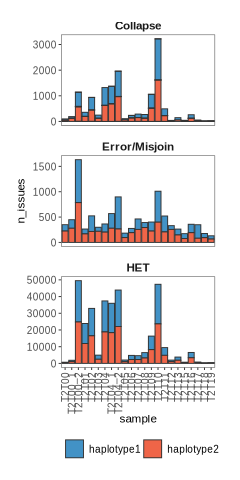

In [ ]:
fig1_C_width = 2
fig1_C_height = 4

fig1_C_issues_nucflag <- ggplot(dt_issues_classified %>% filter(source == "Nucflag")) +
    geom_bar(aes(x = sample, y = n_issues, fill = haplotype),
        stat = "identity",
        col = "grey20") +
    facet_wrap(~ feature_group, ncol = 1, scales = "free_y") +
    scale_fill_manual(
        values = col_haplotype,
        name = ""
    ) +
    theme(
        legend.position = "bottom",
        axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1, size = 6)
    )

ggsave("../../doc/figures/fig1_C_issues_nucflag.png", fig1_C_issues_nucflag, width = fig1_C_width, height = fig1_C_height)
ggsave("../../doc/figures/fig1_C_issues_nucflag.pdf", fig1_C_issues_nucflag, width = fig1_C_width, height = fig1_C_height)

options(repr.plot.width = fig1_C_width, repr.plot.height = fig1_C_height)
fig1_C_issues_nucflag

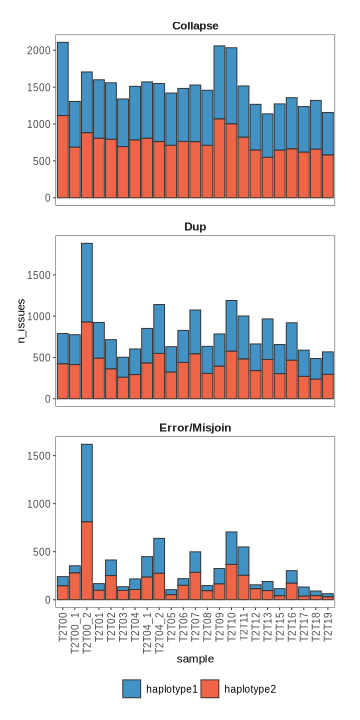

In [47]:
bfig1_C_width = 2
fig1_C_height = 4

fig1_C_issues_flagger <- ggplot(dt_issues_classified %>% filter(source == "Flagger")) +
    geom_bar(aes(x = sample, y = n_issues, fill = haplotype),
        stat = "identity",
        col = "grey20") +
    facet_wrap(~ feature_group, ncol = 1, scales = "free_y") +
    scale_fill_manual(
        values = col_haplotype,
        name = ""
    ) +
    theme(
        legend.position = "bottom",
        axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1, size = 6)
    )

ggsave("../../doc/figures/fig1_C_issues_flagger.png", fig1_C_issues_flagger, width = fig1_C_width +1 , height = fig1_C_height + 2)
ggsave("../../doc/figures/fig1_C_issues_flagger.pdf", fig1_C_issues_flagger, width = fig1_C_width +1, height = fig1_C_height+2)

options(repr.plot.width = fig1_C_width +1, repr.plot.height = fig1_C_height + 2)
fig1_C_issues_flagger

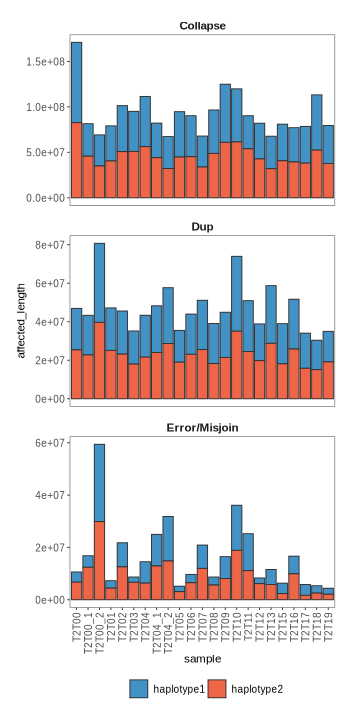

In [48]:
# Plot length of regions flagged as potential issues per sample 

fig1_C_width = 2
fig1_C_height = 4

fig1_C_issues_flagger <- ggplot(dt_issues_classified %>% filter(source == "Flagger")) +
    geom_bar(aes(x = sample, y = affected_length, fill = haplotype),
        stat = "identity",
        col = "grey20") +
    facet_wrap(~ feature_group, ncol = 1, scales = "free_y") +
    scale_fill_manual(
        values = col_haplotype,
        name = ""
    ) +
    theme(
        legend.position = "bottom",
        axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1, size = 6)
    )

ggsave("../../doc/figures/fig1_C_issues_flagger_length.png", fig1_C_issues_flagger, width = fig1_C_width +1, height = fig1_C_height + 2)
ggsave("../../doc/figures/fig1_C_issues_flagger_length.pdf", fig1_C_issues_flagger, width = fig1_C_width +1, height = fig1_C_height + 2)

options(repr.plot.width = fig1_C_width +1, repr.plot.height = fig1_C_height + 2)
fig1_C_issues_flagger

## Supp figure:

Use Ideogram plot to give a good overview of easy and challenging regions of the geneom.
Should at a first glance show: 
- Where our T2T assemblies were successful
- Where our T2T assemblies failed to generate complete chromosomes
- Regions with potential errors / gaps / misassemblies

Ideogram requires specific data formats:
 1. Karyotype file: chromosome, start, end (and optionally: CE_start, CE_end for centromere)
 2. Data file: chromosome, start, end, value (for overlays)

 Uses [ggideogram](https://github.com/dxsbiocc/ggiodeogram)


Note: Additional issue types / metrics added in review process:

- Contig ends in multi-mapping genes
- Mendelian Error rates

In [128]:
# Calculate weighted issues for heatmap
dt_issues_raw <- read_tsv("../../doc/tables/for_plots/assembly_issues_all_samples.tsv", show_col_types = FALSE)

weight_key <- if ("sample" %in% names(dt_issues_raw)) "sample" else "source"
key_sym <- rlang::sym(weight_key)

# Define facet labels - easily customizable
facet_labels <- c(
    "Error/Misjoin" = "Errors & Misjoins",
    "Collapse" = "Collapsed Regions",
    "Dup" = "Duplications",
    "HET" = "Heterozygous Sites",
    "N_region" = "N Regions (Gaps)",
    "Difficult Regions" = "Known Difficult Regions"
)

head(dt_issues_raw)

dt_issues_classified <- dt_issues_raw %>%
    mutate(
        feature_type = str_remove(feature_type, "_windowed$")
    ) %>%
    mutate(
        feature_group = case_when(
            str_detect(feature_type, regex("Err|MISJOIN", ignore_case = TRUE)) ~ "Error/Misjoin",
            str_detect(feature_type, regex("COLLAPSE|Col", ignore_case = TRUE)) ~ "Collapse",
            TRUE ~ feature_type
        ),
        feature_group = replace_na(feature_group, "Other")
    ) %>%
    filter(feature_type != "Hap")

head(dt_issues_classified)


Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”


sample,source,chr,start,end,feature_type
<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
T2T00,Flagger,chr1,5655,138553,Hap
T2T00,Flagger,chr1,138553,174566,Dup
T2T00,Flagger,chr1,216657,506601,Hap
T2T00,Flagger,chr1,801512,885515,Dup
T2T00,Flagger,chr1,1040538,1716307,Hap
T2T00,Flagger,chr1,2343932,2362140,Err


sample,source,chr,start,end,feature_type,feature_group
<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
T2T00,Flagger,chr1,138553,174566,Dup,Dup
T2T00,Flagger,chr1,801512,885515,Dup,Dup
T2T00,Flagger,chr1,2343932,2362140,Err,Error/Misjoin
T2T00,Flagger,chr1,19538879,19542882,Dup,Dup
T2T00,Flagger,chr1,19550881,19562881,Err,Error/Misjoin
T2T00,Flagger,chr1,26608957,26648952,Dup,Dup


In [129]:
# Calculate weighted issues

# Weighting: inverse by total issues per sample
# This DOWNWEIGHTS samples with many issues (prevents one bad sample from dominating)
# Alternative: set all weights to 1 for equal representation
sample_weights <- dt_issues_classified %>%
    count(!!key_sym, name = "n_issues") %>%
    mutate(weight = 1 / pmax(n_issues, 1))
    # For equal weighting, use: mutate(weight = 1)

dt_issues_weighted <- dt_issues_classified %>%
    left_join(sample_weights, by = weight_key) %>%
    mutate(weight = replace_na(weight, 1))

bin_size <- 2e6
issues_heatmap <- dt_issues_weighted %>%
    filter(str_detect(chr, "^chr[0-9XY]+$")) %>%
    left_join(karyotype_chm13 %>% select(chr, chr_length = end), by = "chr") %>%
    mutate(
        bin_start = pmax(1, floor(start / bin_size) * bin_size + 1),
        bin_end = pmin(bin_start + bin_size - 1, chr_length)
    ) %>%
    group_by(feature_group, chr, bin_start, bin_end) %>%
    summarise(
        weighted_count = sum(weight, na.rm = TRUE),  # Sum of weights for all issues in this bin
        n_issues = n(),  # Raw count of issues
        .groups = "drop"
    ) %>%
    group_by(feature_group) %>%
    mutate(
        max_weighted = max(weighted_count, na.rm = TRUE),
        scaled_intensity = if_else(max_weighted > 0, weighted_count / max_weighted, 0)
    ) %>%
    ungroup() %>%
    select(-max_weighted)

# Define facet order
preferred_order <- c("Error/Misjoin", "Collapse", "Dup")
group_levels <- c(preferred_order, setdiff(unique(issues_heatmap$feature_group), preferred_order), "Difficult Regions")
issues_heatmap <- issues_heatmap %>%
    mutate(feature_group = factor(feature_group, levels = group_levels, labels = facet_labels[group_levels]))

# Get arm boundaries from cytoband for background
arm_boundaries <- cytoband %>%
    group_by(chr, arm) %>%
    summarise(
        arm_start = min(start),
        arm_end = max(end),
        .groups = "drop"
    )

# Assign arm based on bin midpoint
issues_heatmap <- issues_heatmap %>%
    mutate(bin_mid = (bin_start + bin_end) / 2) %>%
    left_join(
        arm_boundaries %>% mutate(chr = as.character(chr)),
        by = "chr",
        relationship = "many-to-many"
    ) %>%
    filter(bin_mid >= arm_start & bin_mid <= arm_end) %>%
    select(-bin_mid, -arm_start, -arm_end)


# Update facet labels for karyotype_bg
group_levels_labeled <- facet_labels[group_levels]

karyotype_bg <- tidyr::crossing(
    arm_boundaries,
    feature_group = group_levels_labeled
) %>%
    rename(start = arm_start, end = arm_end) %>%
    mutate(
        chr = factor(chr, levels = levels(karyotype_chm13$chr)),
        feature_group = factor(feature_group, levels = group_levels_labeled)
    )


# Flip coordinates: use GLOBAL max so all chromosomes are top-aligned
chr_max <- karyotype_chm13 %>% select(chr, chr_max = end)
global_max <- max(karyotype_chm13$end)

issues_heatmap <- issues_heatmap %>%
    mutate(
        bin_start_flip = global_max - bin_end,
        bin_end_flip = global_max - bin_start
    ) %>%
    select(-bin_start, -bin_end) %>%
    rename(bin_start = bin_start_flip, bin_end = bin_end_flip)

karyotype_bg <- karyotype_bg %>%
    mutate(
        start_flip = global_max - end,
        end_flip = global_max - start
    ) %>%
    select(-start, -end) %>%
    rename(start = start_flip, end = end_flip)

# Swap arm labels so ideogram rounding is correct after flip
issues_heatmap <- issues_heatmap %>%
    mutate(arm = case_when(arm == "p" ~ "q", arm == "q" ~ "p", TRUE ~ arm))
karyotype_bg <- karyotype_bg %>%
    mutate(arm = case_when(arm == "p" ~ "q", arm == "q" ~ "p", TRUE ~ arm))

In [130]:
for (c in  paste0("chr", c(1:22, "X", "Y"))) {
    print(c)
}

c = "chr21"

ideogram_hap1 <- ggplot(cytoband %>% filter (chr == c)) +
    geom_ideogram(aes(
        x = chr,
        ymin = start, ymax = end,
        chrom = chr,
        arm = arm),
        fill = "#4292c6",
            radius = unit(10, 'pt'), width = 1, linewidth = .2,
            colour = 'grey20', alpha = 1, show.legend = F
    ) + 
    geom_ideogram(aes(
        x = chr,
        ymin = start, ymax = end,
        chrom = chr,
        arm = arm,
        fill = gieStain),
        radius = unit(10, 'pt'), width = 1, linewidth = .2,
        colour = 'grey20', alpha = 0.2, show.legend = F
    ) + 
    scale_fill_manual(values = cytoband_colors) +
    theme_void()

ideogram_hap2 <- ggplot(cytoband %>% filter (chr == c)) +
    geom_ideogram(aes(
        x = chr,
        ymin = start, ymax = end,
        chrom = chr,
        arm = arm),
        fill = "#ef6548",
        radius = unit(10, 'pt'), width = 1, linewidth = .2,
        colour = 'grey20', alpha = 1, show.legend = F
    ) + 
    geom_ideogram(aes(
        x = chr,
        ymin = start, ymax = end,
        chrom = chr,
        arm = arm,
        fill = gieStain),
        radius = unit(10, 'pt'), width = 1, linewidth = .2,
        colour = 'grey20', alpha = 0.2, show.legend = F
    ) + 
    scale_fill_manual(values = cytoband_colors) +
    theme_void()

ggsave(paste0("../../doc/figures/ideograms/ideogram_", c, "_hap1.pdf"), ideogram_hap1, width = 0.5, height = 8)
ggsave(paste0("../../doc/figures/ideograms/ideogram_", c, "_hap2.pdf"), ideogram_hap2, width = 0.5, height = 8)


options(repr.plot.width = 0.5, repr.plot.height = 8)
ideogram_hap1
ideogram_hap2

[1] "chr1"
[1] "chr2"
[1] "chr3"
[1] "chr4"
[1] "chr5"
[1] "chr6"
[1] "chr7"
[1] "chr8"
[1] "chr9"
[1] "chr10"
[1] "chr11"
[1] "chr12"
[1] "chr13"
[1] "chr14"
[1] "chr15"
[1] "chr16"
[1] "chr17"
[1] "chr18"
[1] "chr19"
[1] "chr20"
[1] "chr21"
[1] "chr22"
[1] "chrX"
[1] "chrY"


Warning message:
“internal error 1 in R_decompress1 with libdeflate”


ERROR: Error: lazy-load database '/mnt/storage5/users/ahgrosc1/environments/envs/r-notebooks/lib/R/library/ggideogram/R/ggideogram.rdb' is corrupt


In [131]:
ideogram_stain <- ggplot(cytoband) +
    geom_ideogram(aes(
        x = chr,
        ymin = start, ymax = end,
        chrom = chr,
        arm = arm,
        fill = gieStain),
        radius = unit(10, 'pt'), width = 1, linewidth = .2,
        colour = 'grey20', alpha = 0.2, show.legend = F
    ) + 
    scale_fill_manual(values = cytoband_colors) +
    theme_void()

ideogram_hap1 <- ggplot(karyotype_bg) +
    geom_ideogram(aes(
        x = chr,
        ymin = start, ymax = end,
        chrom = chr,
        arm = arm),
        radius = unit(10, 'pt'), width = 1, linewidth = .2,
        colour = 'grey20', fill = "#4292c6", show.legend = F
    ) + 
    theme_void()

options(repr.plot.width = 10, repr.plot.height = 8)
#ideogram_hap1
#ideogram_stain

ggsave("../../doc/figures/ideogram_hap1.pdf", ideogram_hap1, width = 10, height = 8)
ggsave("../../doc/figures/ideogram_stain.pdf", ideogram_stain, width = 10, height = 8)

Warning message:
“restarting interrupted promise evaluation”
Warning message:
“internal error 1 in R_decompress1 with libdeflate”


ERROR: Error: lazy-load database '/mnt/storage5/users/ahgrosc1/environments/envs/r-notebooks/lib/R/library/ggideogram/R/ggideogram.rdb' is corrupt


In [132]:
# Version without difficult regions panel
fig1_D_ideogram_heatmap_no_difficult <- ggplot() +
    # Issues heatmap 
    geom_ideogram(
        data = issues_heatmap %>% filter(feature_group != facet_labels["Difficult Regions"]),
        aes(x = chr, ymin = bin_start, ymax = bin_end, chrom = chr, arm = arm, fill = scaled_intensity),
        width = 0.7,
        radius = unit(2.5, "pt"),
        colour = NA
    ) +
    # First fill scale (for issues - continuous)
    scale_fill_gradientn(
        colours = c("#f7f7f7", "#fddbc7", "#f4a582", "#d6604d", "#b2182b"),
        values = scales::rescale(c(0, 0.25, 0.5, 0.75, 1)),
        name = "Weighted issue\nsignal",
        limits = c(0, 1),
        labels = scales::label_percent(accuracy = 1),
        na.value = "transparent",
        guide = guide_colorbar(
            title.position = "top",
            title.hjust = 0.5,
            barwidth = unit(4, "cm"),
            barheight = unit(0.4, "cm")
        )
    ) +
    # Background outline
    geom_ideogram(
        data = karyotype_bg %>% filter(feature_group != facet_labels["Difficult Regions"]),
        aes(x = chr, ymin = start, ymax = end, chrom = chr, arm = arm),
        fill = NA,
        colour = "grey40",
        width = 0.7,
        radius = unit(2.5, "pt"),
        linewidth = 0.5,
        show.legend = FALSE
    ) +
    facet_wrap(~ feature_group, ncol = 2) +
    scale_x_discrete(labels = function(x) gsub("chr", "", x)) +
    theme(
        axis.title = element_blank(),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 8),
        panel.grid = element_blank(),
        strip.text = element_text(face = "bold", size = 10),
        legend.position = "bottom",
        legend.box = "horizontal"
    )

ggsave("../../doc/figures/fig1_D_ideogram_heatmap_no_difficult.png", fig1_D_ideogram_heatmap_no_difficult, width = sizes[["D"]]["1"], height = sizes[["D"]]["2"])
ggsave("../../doc/figures/fig1_D_ideogram_heatmap_no_difficult.pdf", fig1_D_ideogram_heatmap_no_difficult, width = sizes[["D"]]["1"], height = sizes[["D"]]["2"])

options(repr.plot.width = sizes[["D"]]["1"], repr.plot.height = sizes[["D"]]["2"])
fig1_D_ideogram_heatmap_no_difficult

Warning message:
“restarting interrupted promise evaluation”


Warning message:
“internal error 1 in R_decompress1 with libdeflate”


ERROR: Error: lazy-load database '/mnt/storage5/users/ahgrosc1/environments/envs/r-notebooks/lib/R/library/ggideogram/R/ggideogram.rdb' is corrupt


In [ ]:
# Create dataframe with known difficult-to-assemble regions (T2T-CHM13 v2.0 coordinates)
# Sources cited below
difficult_regions <- tribble(
    ~chr, ~start, ~end, ~region_name, ~category, ~source,
    # 45S rDNA arrays on acrocentric chromosomes (short arms)
    # Source: Nurk et al. 2022 Science, Fig 2; UCSC RepeatMasker
    "chr13", 1, 16000000, "45S rDNA", "rRNA", "Nurk2022",
    "chr14", 1, 16000000, "45S rDNA", "rRNA", "Nurk2022",
    "chr15", 1, 17000000, "45S rDNA", "rRNA", "Nurk2022",
    "chr21", 1, 11000000, "45S rDNA", "rRNA", "Nurk2022",
    "chr22", 1, 15000000, "45S rDNA", "rRNA", "Nurk2022",
    # 5S rRNA cluster - Source: Stults et al. 2008 Genome Res
    "chr1", 228600000, 228800000, "5S rRNA", "rRNA", "Stults2008",
    # MHC / HLA region - Source: IMGT/HLA database; chr6:28,510,120-33,480,577 (GRCh38)
    "chr6", 28500000, 33500000, "MHC/HLA", "Immune", "IMGT_HLA",
    # Immunoglobulin loci - Source: IMGT database
    "chr14", 105600000, 107000000, "IGH", "Immune", "IMGT",
    "chr2", 88800000, 90200000, "IGK", "Immune", "IMGT",
    "chr22", 22000000, 23200000, "IGL", "Immune", "IMGT",
    # KIR locus - Source: IPD-KIR database
    "chr19", 54000000, 54400000, "KIR", "Immune", "IPD_KIR",
    # Beta-defensin cluster - Source: Hollox et al. 2008 Am J Hum Genet
    "chr8", 6300000, 12500000, "Beta-defensin", "Segmental Dup", "Hollox2008",
    # Amylase gene cluster - Source: Perry et al. 2007 Nat Genet
    "chr1", 103500000, 104000000, "AMY cluster", "Segmental Dup", "Perry2007",
    # Large segmental duplication regions - Source: UCSC Segmental Dups track
    "chr9", 40000000, 45000000, "9p12", "Segmental Dup", "UCSC_SegDup",
    "chr16", 34000000, 36500000, "16p11.2", "Segmental Dup", "UCSC_SegDup",
    "chr15", 20000000, 23000000, "15q11-q13", "Segmental Dup", "UCSC_SegDup",
    # Subtelomeric regions - Source: Riethman 2008 Chromosome Res
    "chr1", 1, 500000, "1p subtel", "Subtelomere", "Riethman2008",
    "chr1", 248300000, 248387328, "1q subtel", "Subtelomere", "Riethman2008",
    "chr2", 1, 500000, "2p subtel", "Subtelomere", "Riethman2008",
    "chr2", 242100000, 242193529, "2q subtel", "Subtelomere", "Riethman2008",
    # Y chromosome heterochromatin - Source: Skaletsky et al. 2003 Nature
    "chrY", 10300000, 56887902, "Yq heterochromatin", "Heterochromatin", "Skaletsky2003",
    # Pericentromeric heterochromatin - Source: Altemose et al. 2022 Science
    "chr1", 122000000, 125100000, "1q12 het", "Heterochromatin", "Altemose2022",
    "chr9", 45000000, 62000000, "9q12 het", "Heterochromatin", "Altemose2022",
    "chr16", 36500000, 46500000, "16q11.2 het", "Heterochromatin", "Altemose2022"
) %>%
    filter(chr %in% levels(karyotype_chm13$chr)) %>%
    mutate(chr = factor(chr, levels = levels(karyotype_chm13$chr)))

# Print sources for reference
cat("Sources for difficult regions:\n")
cat("- Nurk2022: Nurk et al. (2022) Science. DOI: 10.1126/science.abj6987\n")
cat("- Altemose2022: Altemose et al. (2022) Science. DOI: 10.1126/science.abl4178\n")
cat("- IMGT_HLA: https://www.ebi.ac.uk/ipd/imgt/hla/\n")
cat("- IMGT: https://www.imgt.org/\n")
cat("- IPD_KIR: https://www.ebi.ac.uk/ipd/kir/\n")
cat("- UCSC_SegDup: https://genome.ucsc.edu/cgi-bin/hgTrackUi?db=hs1&g=genomicSuperDups\n")
cat("- Stults2008: Stults et al. (2008) Genome Res. DOI: 10.1101/gr.6858507\n")
cat("- Hollox2008: Hollox et al. (2008) Am J Hum Genet. DOI: 10.1016/j.ajhg.2007.12.009\n")
cat("- Perry2007: Perry et al. (2007) Nat Genet. DOI: 10.1038/ng2123\n")
cat("- Riethman2008: Riethman (2008) Chromosome Res. DOI: 10.1007/s10577-007-1199-2\n")
cat("- Skaletsky2003: Skaletsky et al. (2003) Nature. DOI: 10.1038/nature01722\n")

# UCSC track download links (T2T-CHM13 v2.0 / hs1):
# Segmental Dups: https://genome.ucsc.edu/cgi-bin/hgTables?hgta_doSchemaDb=hg18&hgta_doSchemaTable=genomicSuperDups")
# RepeatMasker: https://hgdownload.soe.ucsc.edu/goldenPath/hs1/bigZips/hs1.repeatMasker.out.gz\n")
# Centromeres: https://hgdownload.soe.ucsc.edu/goldenPath/hs1/database/centromeres.txt.gz\n")

# First, split regions at arm boundaries to ensure correct arm assignment
difficult_with_arms <- difficult_regions %>%
    left_join(
        arm_boundaries %>% mutate(chr = as.character(chr)),
        by = "chr",
        relationship = "many-to-many"
    ) %>%
    # Calculate overlap between region and arm
    mutate(
        overlap_start = pmax(start, arm_start),
        overlap_end = pmin(end, arm_end)
    ) %>%
    # Keep only actual overlaps
    filter(overlap_start < overlap_end) %>%
    # Use the overlapping portion as the new region
    mutate(
        start = overlap_start,
        end = overlap_end
    ) %>%
    select(chr, start, end, region_name, category, source, arm)

# Now bin the split regions
bin_size <- 2e6
difficult_binned <- difficult_with_arms %>%
    left_join(karyotype_chm13 %>% select(chr, chr_length = end), by = "chr") %>%
    rowwise() %>%
    mutate(
        bins = list(tibble(
            bin_start = seq(
                pmax(1, floor(start / bin_size) * bin_size + 1),
                floor(end / bin_size) * bin_size + 1,
                by = bin_size
            )
        ) %>% mutate(bin_end = pmin(bin_start + bin_size - 1, chr_length)))
    ) %>%
    unnest(bins) %>%
    ungroup() %>%
    select(chr, bin_start, bin_end, region_name, category, arm) %>%
    distinct()

# Create difficult_heatmap with proper factor levels
difficult_heatmap <- difficult_binned %>%
    mutate(feature_group = factor(
        facet_labels["Difficult Regions"], 
        levels = group_levels_labeled
    )) %>%
    select(feature_group, chr, bin_start, bin_end, category, arm)

difficult_heatmap <- difficult_binned %>%
    mutate(feature_group = factor(
        facet_labels["Difficult Regions"], 
        levels = group_levels_labeled
    )) %>%
    select(feature_group, chr, bin_start, bin_end, category, arm) %>%
    left_join(chr_max, by = "chr") %>%
    mutate(
        bin_start_flip = chr_max - bin_end,
        bin_end_flip = chr_max - bin_start
    ) %>%
    select(-bin_start, -bin_end, -chr_max) %>%
    rename(bin_start = bin_start_flip, bin_end = bin_end_flip)

difficult_heatmap <- difficult_heatmap %>%
    mutate(arm = case_when(arm == "p" ~ "q", arm == "q" ~ "p", TRUE ~ arm))


head(difficult_heatmap)
print(paste("Total difficult region bins:", nrow(difficult_heatmap)))

Sources for difficult regions:
- Nurk2022: Nurk et al. (2022) Science. DOI: 10.1126/science.abj6987
- Altemose2022: Altemose et al. (2022) Science. DOI: 10.1126/science.abl4178
- IMGT_HLA: https://www.ebi.ac.uk/ipd/imgt/hla/
- IMGT: https://www.imgt.org/
- IPD_KIR: https://www.ebi.ac.uk/ipd/kir/
- UCSC_SegDup: https://genome.ucsc.edu/cgi-bin/hgTrackUi?db=hs1&g=genomicSuperDups
- Stults2008: Stults et al. (2008) Genome Res. DOI: 10.1101/gr.6858507
- Hollox2008: Hollox et al. (2008) Am J Hum Genet. DOI: 10.1016/j.ajhg.2007.12.009
- Perry2007: Perry et al. (2007) Nat Genet. DOI: 10.1038/ng2123
- Riethman2008: Riethman (2008) Chromosome Res. DOI: 10.1007/s10577-007-1199-2
- Skaletsky2003: Skaletsky et al. (2003) Nature. DOI: 10.1038/nature01722


feature_group,chr,category,arm,bin_start,bin_end
<fct>,<chr>,<chr>,<chr>,<dbl>,<dbl>
Known Difficult Regions,chr13,rRNA,q,111566686,113566685
Known Difficult Regions,chr13,rRNA,q,109566686,111566685
Known Difficult Regions,chr13,rRNA,q,107566686,109566685
Known Difficult Regions,chr13,rRNA,q,105566686,107566685
Known Difficult Regions,chr13,rRNA,q,103566686,105566685
Known Difficult Regions,chr13,rRNA,q,101566686,103566685


[1] "Total difficult region bins: 114"


In [ ]:
# Define colors for difficult region categories
difficult_colors <- c(
    "rRNA" = "#e41a1c",
    "Immune" = "#377eb8", 
    "Segmental Dup" = "#4daf4a",
    "Subtelomere" = "#984ea3",
    "Heterochromatin" = "#ff7f00"
)

fig1_D_ideogram_heatmap <- ggplot() +
    # Issues heatmap (for non-Difficult Regions panels)
    geom_ideogram(
        data = issues_heatmap,
        aes(x = chr, ymin = bin_start, ymax = bin_end, chrom = chr, arm = arm, fill = scaled_intensity),
        width = 0.7,
        radius = unit(2.5, "pt"),
        colour = NA
    ) +
    # First fill scale (for issues - continuous)
    scale_fill_gradientn(
        colours = c("#f7f7f7", "#fddbc7", "#f4a582", "#d6604d", "#b2182b"),
        values = scales::rescale(c(0, 0.25, 0.5, 0.75, 1)),
        name = "Weighted issue\nsignal",
        limits = c(0, 1),
        labels = scales::label_percent(accuracy = 1),
        na.value = "transparent"
    ) +
    # Reset fill scale for difficult regions
    ggnewscale::new_scale_fill() +
    # Add difficult regions with category colors
    geom_ideogram(
        data = difficult_heatmap,
        aes(x = chr, ymin = bin_start, ymax = bin_end, chrom = chr, arm = arm, fill = category),
        width = 0.7,
        radius = unit(2.5, "pt"),
        colour = NA
    ) +
    # Background outline
    geom_ideogram(
        data = karyotype_bg,
        aes(x = chr, ymin = start, ymax = end, chrom = chr, arm = arm),
        fill = NA,
        colour = "grey40",
        width = 0.7,
        radius = unit(2.5, "pt"),
        linewidth = 0.5,
        show.legend = FALSE
    ) +
    # Second fill scale (for difficult regions - discrete)
    scale_fill_manual(
        values = difficult_colors,
        name = "Region type",
        na.translate = FALSE
    ) +
    facet_wrap(~ feature_group, ncol = 2) +
    scale_x_discrete(labels = function(x) gsub("chr", "", x)) +
    theme(
        axis.title = element_blank(),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 8),
        panel.grid = element_blank(),
        strip.text = element_text(face = "bold", size = 10),
        legend.position = "bottom",
        legend.box = "horizontal"
    ) +
    guides(
        fill = guide_legend(
            title.position = "top",
            title.hjust = 0.5,
            nrow = 1
        )
    )

ggsave("../../doc/figures/fig1_D_ideogram_heatmap.png", fig1_D_ideogram_heatmap, width = sizes[["D"]]["1"], height = sizes[["D"]]["2"])
ggsave("../../doc/figures/fig1_D_ideogram_heatmap.pdf", fig1_D_ideogram_heatmap, width = sizes[["D"]]["1"], height = sizes[["D"]]["2"])

options(repr.plot.width = sizes[["D"]]["1"], repr.plot.height = sizes[["D"]]["2"])
fig1_D_ideogram_heatmap

ERROR: Error in loadNamespace(x): there is no package called ‘ggnewscale’


## F: NGX Plot

NGX plot showing assembly contiguity for all samples and haplotypes.
This plot is not used in the Publication

In [133]:
# Read assembly length data for samples
dt_lengths <- read_tsv("../../doc/tables/for_plots/assembly_lengths_all_samples.tsv", show_col_types = FALSE)

# Read assembly length data for HPRC
dt_lengths_hprc <- read_tsv("../../doc/tables/for_plots/assembly_lengths_hprc.tsv", show_col_types = FALSE) %>%
    mutate(source = "HPRC")

# Add source label to samples
dt_lengths <- dt_lengths %>%
    mutate(source = "Samples")

# Calculate NGX values for each sample and haplotype
calculate_ngx <- function(lengths, genome_size = 3.1e9) {
    # Sort lengths in descending order
    sorted_lengths <- sort(lengths, decreasing = TRUE)
    cumsum_lengths <- cumsum(sorted_lengths)
    
    # Calculate NGX values
    ngx_values <- seq(0, 100, by = 1)
    ngx_lengths <- sapply(ngx_values, function(x) {
        threshold <- genome_size * (x / 100)
        idx <- which(cumsum_lengths >= threshold)[1]
        if (is.na(idx)) return(0)
        return(sorted_lengths[idx])
    })
    
    tibble(
        ngx = ngx_values,
        length = ngx_lengths
    )
}

# Calculate NGX for samples
dt_ngx <- dt_lengths %>%
    group_by(sample, haplotype, source) %>%
    summarise(
        ngx_data = list(calculate_ngx(length)),
        .groups = "drop"
    ) %>%
    unnest(ngx_data) %>%
    mutate(
        haplotype = recode(haplotype,
            "haplotype1" = "Hap 1",
            "haplotype2" = "Hap 2"
        )
    )

# Calculate NGX for HPRC
dt_ngx_hprc <- dt_lengths_hprc %>%
    group_by(sample, haplotype, source) %>%
    summarise(
        ngx_data = list(calculate_ngx(length)),
        .groups = "drop"
    ) %>%
    unnest(ngx_data) %>%
    mutate(
        haplotype = recode(haplotype,
            "haplotype1" = "Hap 1",
            "haplotype2" = "Hap 2"
        )
    )

head(dt_ngx)
head(dt_ngx_hprc)

sample,haplotype,source,ngx,length
<chr>,<chr>,<chr>,<dbl>,<dbl>
T2T00,Hap 1,Samples,0,245398328
T2T00,Hap 1,Samples,1,245398328
T2T00,Hap 1,Samples,2,245398328
T2T00,Hap 1,Samples,3,245398328
T2T00,Hap 1,Samples,4,245398328
T2T00,Hap 1,Samples,5,245398328


sample,haplotype,source,ngx,length
<chr>,<chr>,<chr>,<dbl>,<dbl>
HG002,Hap 1,HPRC,0,252060741
HG002,Hap 1,HPRC,1,252060741
HG002,Hap 1,HPRC,2,252060741
HG002,Hap 1,HPRC,3,252060741
HG002,Hap 1,HPRC,4,252060741
HG002,Hap 1,HPRC,5,252060741


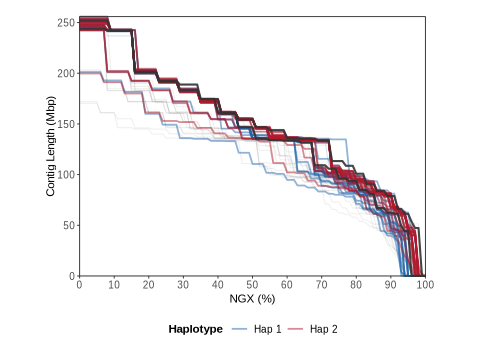

In [134]:
# Create NGX plot with HPRC background
fig1_F_ngx <- ggplot() +
    # Add HPRC data as grey background
    geom_line(
        data = dt_ngx_hprc[dt_ngx_hprc$sample != "HG002", ],
        aes(x = ngx, y = length / 1e6, group = interaction(sample, haplotype)),
        alpha = 0.15,
        linewidth = 0.3,
        color = "grey60"
    ) +
    # Add sample data on top
    geom_line(
        data = dt_ngx,
        aes(x = ngx, y = length / 1e6, group = interaction(sample, haplotype), color = haplotype),
        alpha = 0.5,
        linewidth = 0.5
    ) +
    geom_line(
        data = dt_ngx_hprc[dt_ngx_hprc$sample == "HG002", ],
        aes(x = ngx, y = length / 1e6, group = interaction(sample, haplotype)),
        color = "grey20",
        alpha = 0.9,
        linewidth = 0.6
    ) +
    scale_y_continuous(
        name = "Contig Length (Mbp)",
        expand = c(0, 0),
        limits = c(0, NA)
    ) +
    scale_x_continuous(
        name = "NGX (%)",
        breaks = seq(0, 100, 10),
        expand = c(0, 0)
    ) +
    coord_cartesian(clip = "off") +
    scale_color_manual(
        name = "Haplotype",
        values = c("Hap 1" = "#2166ac", "Hap 2" = "#b2182b")
    ) +
    theme(
        legend.position = "bottom",
        panel.grid.minor = element_blank(),
        aspect.ratio = as.numeric(sizes[["F"]]["2"]) / as.numeric(sizes[["F"]]["1"])
    )

ggsave("../../doc/figures/fig1_F_ngx.png", fig1_F_ngx, width = sizes[["F"]]["1"], height = sizes[["F"]]["2"])
ggsave("../../doc/figures/fig1_F_ngx.pdf", fig1_F_ngx, width = sizes[["F"]]["1"], height = sizes[["F"]]["2"])

options(repr.plot.width = as.numeric(sizes[["F"]]["1"]), repr.plot.height = as.numeric(sizes[["F"]]["2"]))
fig1_F_ngx